# Placing simulations when you care about several outputs

Notebook 2 fit one output of the STIR+SNEC supernova dataset. But each of those 136
simulations returns **three** measured quantities, and a real campaign has to serve all of
them at once — usually with some of them mattering more than others.

`astral-gp` fits an independent GP per output and places at the argmax of a **weighted sum**
of their posterior variances:

$$\\mathrm{score}(x) = \\sum_j w_j \\, \\mathrm{var}_j(x)$$

This notebook shows what those weights actually do to a campaign, and — just as usefully —
when they do very little.

**Data:** [zenodo.org/records/6631964](https://zenodo.org/records/6631964)
([arXiv:2102.01118](https://arxiv.org/abs/2102.01118))

**Contents**
1. Getting the data
2. Three outputs, three characters
3. Independent fits, independent uncertainties
4. What the weights do to a single placement
5. Four campaigns
6. When weighting stops mattering

## 1. Getting the data

As in notebook 2: the archive is **554 MB**, so the download is commented out. Uncomment it,
or set `ASTRAL_LC_PROPERTIES` to a copy you already have.

In [1]:
#-- Uncomment to download the dataset (554 MB) from Zenodo.
#
# import tarfile, urllib.request
#
# URL = 'https://zenodo.org/records/6631964/files/stir_snec_lcs_DR2.tar.gz'
# ARCHIVE = 'stir_snec_lcs_DR2.tar.gz'
#
# print(f'downloading {URL} ...')
# urllib.request.urlretrieve(URL, ARCHIVE)
# print('extracting ...')
# with tarfile.open(ARCHIVE) as tar:
#     tar.extractall('.')
# print('done')

In [2]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np

from astral_gp import Astral

warnings.simplefilter('ignore')

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.25,
                     'axes.spines.top': False, 'axes.spines.right': False})

SEED = 0
#-- Okabe-Ito, one colour per output
OUT_COLORS = ['#0072B2', '#D55E00', '#009E73']
SEED_C, ADDED_C = '#333333', '#D55E00'

LC_PATH = os.environ.get('ASTRAL_LC_PROPERTIES',
                         'stir_snec_lcs_DR2/lc_properties.dat')

if not os.path.isfile(LC_PATH):
    raise FileNotFoundError(
        f'{LC_PATH} not found.\\n'
        'Uncomment the download cell above, or set ASTRAL_LC_PROPERTIES '
        'to point at your copy of lc_properties.dat.')

print(f'using {LC_PATH}')

using stir_snec_lcs_DR2/lc_properties.dat


## 2. Three outputs, three characters

Plateau luminosity, plateau duration and iron-line velocity, all measured at day 50. They
differ by four orders of magnitude in raw units, which is exactly why each output is
standardised by its own mean and standard deviation before fitting.

In [3]:
data = np.loadtxt(LC_PATH)
order = np.argsort(data[:, 1])

pool_X = data[order, 1].reshape(-1, 1)          # ZAMS mass
pool_y = data[order][:, [2, 3, 4]]              # logL50, t_pl, vFe50

NAMES = ['log L50', 't_pl', 'v_Fe50']
UNITS = [r'$\log (L_{50}/\mathrm{erg\,s^{-1}})$', r'$t_\mathrm{pl}$ [days]',
         r'$v_\mathrm{Fe,50}$ [km/s]']
X_LO, X_HI = float(pool_X.min()), float(pool_X.max())

print(f'{len(pool_X)} simulations, {pool_X.shape[1]} input, '
      f'{pool_y.shape[1]} outputs\n')
print(f"{'output':>10} {'min':>12} {'max':>12} {'std':>12}")
for j, name in enumerate(NAMES):
    print(f'{name:>10} {pool_y[:, j].min():>12.4f} '
          f'{pool_y[:, j].max():>12.4f} {pool_y[:, j].std():>12.4f}')

136 simulations, 1 input, 3 outputs

    output          min          max          std
   log L50      41.5515      42.6291       0.2456
      t_pl      59.5774     196.7161      25.6765
    v_Fe50    2739.5975    6153.9845     855.2442


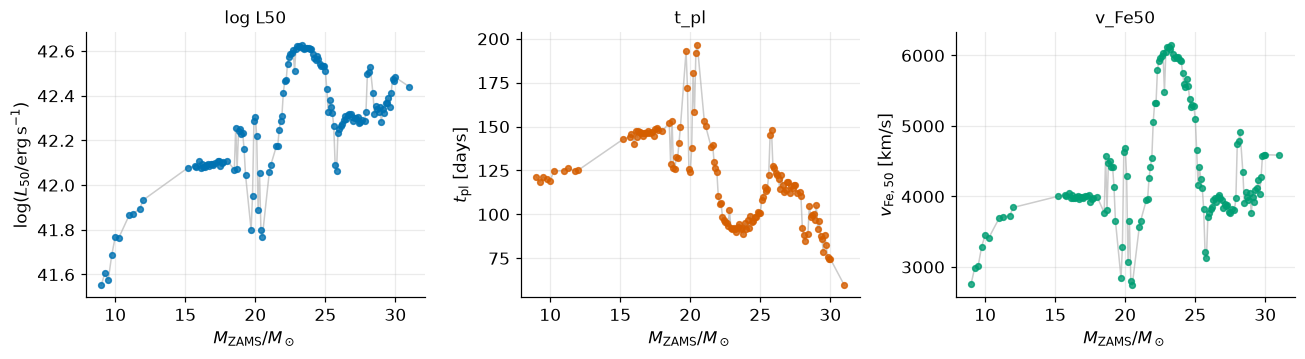

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for j, (ax, name, unit) in enumerate(zip(axes, NAMES, UNITS)):
    ax.plot(pool_X[:, 0], pool_y[:, j], color='#cccccc', lw=1, zorder=1)
    ax.scatter(pool_X[:, 0], pool_y[:, j], color=OUT_COLORS[j], s=14,
               alpha=0.8, zorder=2)
    ax.set_xlabel(r'$M_\mathrm{ZAMS} / M_\odot$')
    ax.set_ylabel(unit)
    ax.set_title(name, fontsize=11)
fig.tight_layout()
plt.show()

## 3. Independent fits, independent uncertainties

This is the part that makes weighting possible at all. scikit-learn's own multi-output GP
shares a single kernel across every column and hands back the *same* posterior standard
deviation for all of them — under that model a weight vector would do nothing.

`astral-gp` fits one GP per output instead, so each gets its own length scale and its own
variance surface. Seed a coarse design and look at what comes back:

In [5]:
N_INITIAL, N_STEPS = 12, 28


def uniform_in_mass(n):
    """Indices of n DISTINCT pool models spaced as evenly in mass as possible."""
    chosen = []
    for target in np.linspace(X_LO, X_HI, n):
        for candidate in np.argsort(np.abs(pool_X[:, 0] - target)):
            if candidate not in chosen:
                chosen.append(int(candidate))
                break
    return np.array(sorted(chosen))


seed_idx = uniform_in_mass(N_INITIAL)

ast = Astral(test_name='multi', n_test=1500, n_eval=3000,
             bounds=[(X_LO, X_HI)], seed=SEED, runs_dir='runs', verbose=False)
ast.set_data(pool_X[seed_idx], pool_y[seed_idx])
ast.train_gp()

print(f'{ast.n_outputs} independent GPs, weights = {ast.weights}\n')
print(f"{'output':>10} {'length scale':>13} {'noise':>10} "
      f"{'band width':>12}")
widths = ast.mean_uncertainty(per_output=True)
for j, name in enumerate(NAMES):
    noise, _, ell = ast.gp.hyperparameters[j]
    print(f'{name:>10} {float(np.atleast_1d(ell)[0]):>13.4f} '
          f'{noise:>10.4f} {widths[j]:>12.4f}')

3 independent GPs, weights = [1. 1. 1.]

    output  length scale      noise   band width
   log L50        1.5200     0.3018       0.3451
      t_pl        0.9477     0.5418      40.7990
    v_Fe50        0.1658     0.0010     503.2605


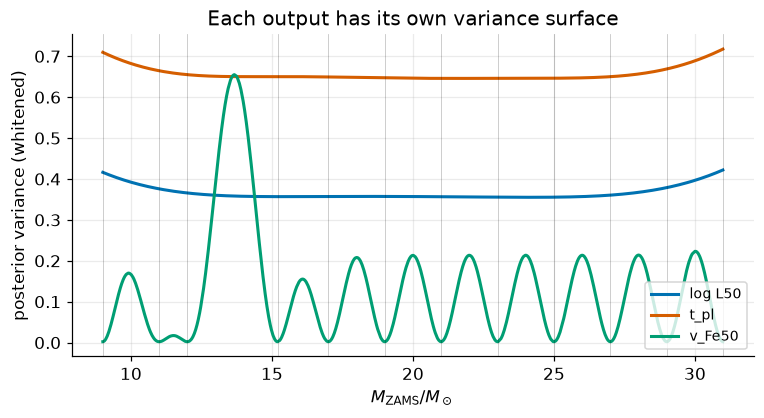

pairwise correlation of the variance surfaces:
   log L50 vs     t_pl: +0.9963
   log L50 vs   v_Fe50: -0.1525
      t_pl vs   v_Fe50: -0.1328


In [6]:
V = ast.gp.variances(ast.test_X)
x = ast.test_X_physical[:, 0]
o = np.argsort(x)

fig, ax = plt.subplots(figsize=(8, 3.8))
for j, name in enumerate(NAMES):
    ax.plot(x[o], V[o, j], color=OUT_COLORS[j], lw=2, label=name)
for m in pool_X[seed_idx, 0]:
    ax.axvline(m, color='k', lw=0.5, alpha=0.25)
ax.set_xlabel(r'$M_\mathrm{ZAMS} / M_\odot$')
ax.set_ylabel('posterior variance (whitened)')
ax.set_title('Each output has its own variance surface')
ax.legend(fontsize=9)
plt.show()

print('pairwise correlation of the variance surfaces:')
for i in range(3):
    for j in range(i + 1, 3):
        r = np.corrcoef(V[:, i], V[:, j])[0, 1]
        print(f'  {NAMES[i]:>8} vs {NAMES[j]:>8}: {r:+.4f}')

The three surfaces share their gross shape — they all spike in the pool's 12–15.2 gap and at
the domain edges, because all three outputs are observed at the *same* masses. But they are
not identical: the fitted length scales differ by nearly an order of magnitude, so each
output's variance decays away from the data at its own rate. `v_Fe50` is rough enough that
its variance recovers within a fraction of a solar mass, while `log L50` stays confident much
further out.

That difference is what the weights have to work with.

## 4. What the weights do to a single placement

The clearest demonstration: same data, same candidates, different weights.

         weighting   next placement
  equal  [1, 1, 1]           13.669
      log L50 only           30.989
         t_pl only           30.989
       v_Fe50 only           13.669


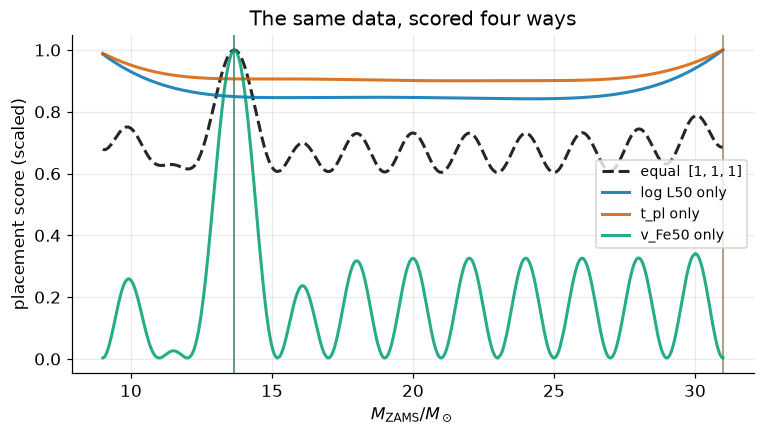

In [7]:
def score_for(weights):
    """Placement score over the same candidates, under a given weighting."""
    a = Astral(test_name='w', n_test=1500, bounds=[(X_LO, X_HI)], seed=SEED,
               weights=weights, runs_dir='runs', verbose=False)
    a.set_data(pool_X[seed_idx], pool_y[seed_idx])
    a.train_gp()
    return a.test_X_physical[:, 0], a.placement_score(), a.place_next()[0][0]


WEIGHTINGS = [('equal  [1, 1, 1]', [1.0, 1.0, 1.0]),
              ('log L50 only', [1.0, 0.0, 0.0]),
              ('t_pl only', [0.0, 1.0, 0.0]),
              ('v_Fe50 only', [0.0, 0.0, 1.0])]

fig, ax = plt.subplots(figsize=(8, 4))
print(f"{'weighting':>18} {'next placement':>16}")
for (label, w), color in zip(WEIGHTINGS, ['k'] + OUT_COLORS):
    xs, score, nxt = score_for(w)
    o = np.argsort(xs)
    ax.plot(xs[o], score[o] / score.max(), color=color, lw=2,
            ls='--' if color == 'k' else '-', alpha=0.85, label=label)
    ax.axvline(nxt, color=color, lw=1, alpha=0.5)
    print(f'{label:>18} {nxt:>16.3f}')

ax.set_xlabel(r'$M_\mathrm{ZAMS} / M_\odot$')
ax.set_ylabel('placement score (scaled)')
ax.set_title('The same data, scored four ways')
ax.legend(fontsize=9)
plt.show()

The weights genuinely move the decision. Prioritising `log L50` or `t_pl` sends the next
simulation to the top of the mass range; prioritising `v_Fe50` sends it into the middle of
the pool's gap instead, because that output's short length scale makes the gap look far more
dangerous than the edges do.

Note which output equal weighting follows: **`v_Fe50`**, whose curve it sits on almost
exactly. That is not a coincidence. After standardisation the outputs are on a common scale,
and `v_Fe50` has by far the shortest length scale (0.17 against 1.52), so its variance
recovers fastest away from the data and is largest wherever there is a gap. A plain sum is
therefore dominated by the roughest output.

**Equal weights are not neutral weights.** If you want a genuinely balanced campaign you may
have to weight *down* the roughest output rather than leaving the vector at ones.

## 5. Four campaigns

Run each weighting for 28 steps and score every resulting surrogate on the simulations it
never used. The interesting question is whether prioritising an output actually buys you
accuracy on it, and what it costs elsewhere.

In [8]:
def held_out_rms(idx):
    """Per-output RMS error on every pool model not in idx."""
    model = Astral(test_name='score', n_test=800, seed=SEED, runs_dir='runs',
                   verbose=False)
    model.set_data(pool_X[idx], pool_y[idx])
    model.train_gp()

    predicted, _, _ = model.gp.predict_physical(
        (pool_X - model.x_mean) / model.x_std)
    held = np.setdiff1d(np.arange(len(pool_X)), idx)
    return np.sqrt(np.mean((predicted[held] - pool_y[held]) ** 2, axis=0))


def campaign(weights, n_steps=N_STEPS):
    """Run a pool campaign under a weighting; return the models it used."""
    a = Astral(test_name='c', n_test=1500, n_eval=3000, bounds=[(X_LO, X_HI)],
               seed=SEED, weights=weights, runs_dir='runs', verbose=False)
    a.set_data(pool_X[seed_idx], pool_y[seed_idx])
    a.set_pool(pool_X, pool_y)
    a.pool_used[seed_idx] = True
    for _ in range(n_steps):
        a.step()
    a.train_gp()
    idx = np.array([int(np.abs(pool_X[:, 0] - v).argmin()) for v in a.X[:, 0]])
    return idx, a


results = {label: campaign(w) for label, w in WEIGHTINGS}

print(f'held-out RMS after {N_STEPS} added simulations '
      f'(N = {N_INITIAL + N_STEPS})\n')
print(f"{'campaign':>18} " + ' '.join(f'{n:>11}' for n in NAMES))
for label, (idx, _) in results.items():
    r = held_out_rms(idx)
    print(f'{label:>18} ' + ' '.join(f'{v:>11.4f}' for v in r))
print(f"{'(data std)':>18} " +
      ' '.join(f'{v:>11.4f}' for v in pool_y.std(axis=0)))

held-out RMS after 28 added simulations (N = 40)

          campaign     log L50        t_pl      v_Fe50
  equal  [1, 1, 1]      0.1508     18.5270    604.9202
      log L50 only      0.1325     16.4280    540.2266
         t_pl only      0.1508     18.5270    604.9202
       v_Fe50 only      0.1337     16.0686    532.3315
        (data std)      0.2456     25.6765    855.2442


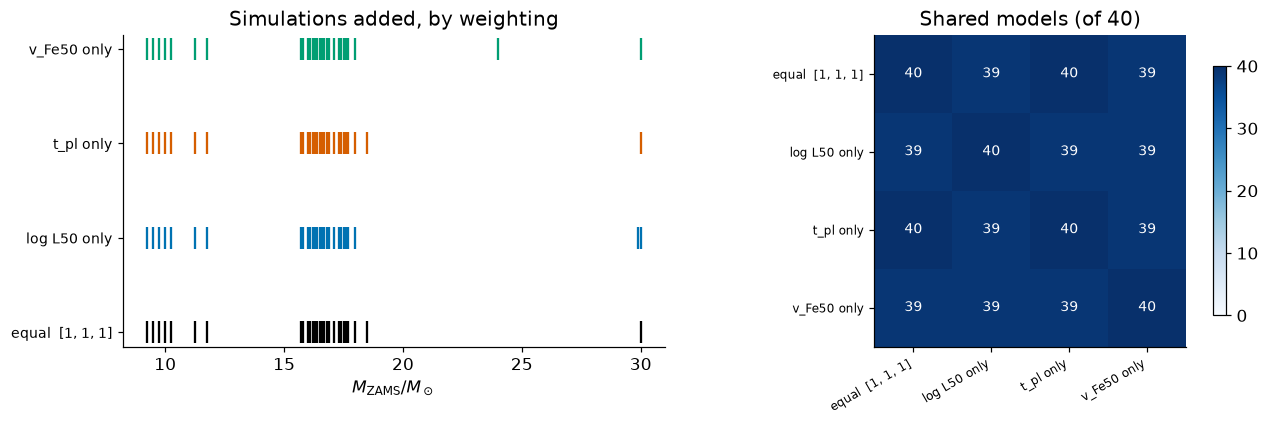

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

#-- where each campaign put its simulations
for k, (label, (idx, a)) in enumerate(results.items()):
    added = a.X[N_INITIAL:, 0]
    axes[0].scatter(added, np.full(len(added), k), marker='|', s=200,
                    color=(['k'] + OUT_COLORS)[k])
axes[0].set_yticks(range(len(results)))
axes[0].set_yticklabels(list(results), fontsize=9)
axes[0].set_xlabel(r'$M_\mathrm{ZAMS} / M_\odot$')
axes[0].set_title('Simulations added, by weighting')
axes[0].grid(False)

#-- how much the campaigns actually differ
labels = list(results)
overlap = np.zeros((len(labels), len(labels)))
for i, li in enumerate(labels):
    for j, lj in enumerate(labels):
        overlap[i, j] = len(set(results[li][0]) & set(results[lj][0]))
im = axes[1].imshow(overlap, cmap='Blues', vmin=0, vmax=N_INITIAL + N_STEPS)
axes[1].set_xticks(range(len(labels)))
axes[1].set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
axes[1].set_yticks(range(len(labels)))
axes[1].set_yticklabels(labels, fontsize=8)
for i in range(len(labels)):
    for j in range(len(labels)):
        axes[1].text(j, i, int(overlap[i, j]), ha='center', va='center',
                     fontsize=9,
                     color='w' if overlap[i, j] > 0.6 * (N_INITIAL + N_STEPS)
                     else 'k')
axes[1].set_title(f'Shared models (of {N_INITIAL + N_STEPS})')
axes[1].grid(False)
fig.colorbar(im, ax=axes[1], shrink=0.8)
fig.tight_layout()
plt.show()

## 6. When weighting stops mattering

The overlap matrix is the honest headline: after 28 steps the four campaigns share almost
every model. The weights changed the *order* in which simulations were acquired, and barely
the final set.

The reason is structural, and worth internalising before reaching for weights on your own
problem:

- **All three outputs are observed at the same inputs.** One simulation returns all of them,
  so every output's variance collapses at exactly the same masses. The surfaces cannot help
  being highly correlated.
- **The input is one-dimensional and the pool is dense.** There are only so many gaps to
  fill; whichever order you fill them in, a large enough budget fills them all.

Weighting bites hardest in the opposite regime: many input dimensions, a tight budget, or
outputs that can be measured independently of one another. Here is the budget effect,
measured directly:

In [10]:
BUDGETS = (4, 8, 16, 28)

print(f"{'budget':>7} {'shared models':>15} {'log L50 RMS':>26}")
print(f"{'':>7} {'(equal vs logL50)':>15} "
      f"{'equal':>12} {'logL50-only':>13}")
for budget in BUDGETS:
    idx_eq, _ = campaign([1.0, 1.0, 1.0], budget)
    idx_l, _ = campaign([1.0, 0.0, 0.0], budget)
    shared = len(set(idx_eq) & set(idx_l))
    r_eq, r_l = held_out_rms(idx_eq)[0], held_out_rms(idx_l)[0]
    print(f'{budget:>7} {shared:>8}/{len(idx_eq):<6} '
          f'{r_eq:>12.4f} {r_l:>13.4f}')

 budget   shared models                log L50 RMS
        (equal vs logL50)        equal   logL50-only
      4       13/16           0.1617        0.1139
      8       16/20           0.1060        0.1138
     16       25/28           0.1196        0.1192
     28       39/40           0.1508        0.1325


The overlap column tells a clean story: at a budget of 4 the two campaigns share 13 of 16
models, and by 28 they share 39 of 40. **Weighting separates campaigns most when the budget
is small**, and its influence decays as the budget fills the space.

The accuracy column is messier, and it would be dishonest to tidy it up. Prioritising
`log L50` helps it at budget 4 and at 28, hurts slightly at 8, and makes no difference at 16.
On a relation this noisy, swapping one simulation for another moves the held-out error by
more than the weighting does; a clean monotone trend would need averaging over many seeds and
many seed designs, not a single run.

The defensible rule is about the design, not the error: **weights decide what you sample
first**, which matters when the budget is tight or the campaign might be cut short, and
matters less once you can afford to cover the space anyway.

## Summary

- Each output gets its **own GP**, its own length scale and its own variance surface. This is
  the difference between weighting doing something and doing nothing.
- Placement maximises $\\sum_j w_j \\mathrm{var}_j(x)$, and the weights visibly move a single
  decision — here, between the top of the mass range and the middle of the pool's gap.
- **Equal weights are not neutral.** After standardisation the roughest output — shortest
  length scale, fastest-recovering variance — dominates a plain sum. Here that is `v_Fe50`,
  and equal weighting follows it almost exactly. Weight it down if you want balance.
- Over a long campaign in 1-D with a dense pool, all weightings converge to nearly the same
  set of simulations — 39 of 40 shared here. Weights change the **order**, which matters at
  small budgets or if you stop early, and little otherwise.
- On a noisy relation the **held-out error is not a reliable readout of the weighting**: a
  single swapped simulation moves it more than the weights do.
- Use `mean_uncertainty(per_output=True)` to watch the outputs separately; the single
  weighted number hides which one is lagging.

Notebook 1 covers the method on analytic targets, including multi-dimensional inputs, where
the budget is always tight relative to the space and weighting has more room to act.